# EDA и гипотезы

Посмотрим глубже на наши данные и выведем из полученного анализа гипотезы и проверим их

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,customer_type,adr,total_of_special_requests,stays_in_nights,has_weekend_nights,guests_categories
0,Resort Hotel,0,342,2015,July,1,PRT,Direct,Direct,0,0,>2,No Deposit,Transient,0.00,0,0,0,Couple
1,Resort Hotel,0,737,2015,July,1,PRT,Direct,Direct,0,0,>2,No Deposit,Transient,0.00,0,0,0,Couple
2,Resort Hotel,0,7,2015,July,1,GBR,Direct,Direct,0,0,0,No Deposit,Transient,75.00,0,1,0,Solo
3,Resort Hotel,0,13,2015,July,1,GBR,Corporate,Corporate,0,0,0,No Deposit,Transient,75.00,0,1,0,Solo
4,Resort Hotel,0,14,2015,July,1,GBR,Online TA,TA/TO,0,0,0,No Deposit,Transient,98.00,1,2,0,Couple
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87159,City Hotel,0,23,2017,August,30,BEL,Offline TA/TO,TA/TO,0,0,0,No Deposit,Transient,96.14,0,7,1,Couple
87160,City Hotel,0,102,2017,August,31,FRA,Online TA,TA/TO,0,0,0,No Deposit,Transient,225.43,2,7,1,Group
87161,City Hotel,0,34,2017,August,31,DEU,Online TA,TA/TO,0,0,0,No Deposit,Transient,157.71,>2,7,1,Couple
87162,City Hotel,0,109,2017,August,31,GBR,Online TA,TA/TO,0,0,0,No Deposit,Transient,104.40,0,7,1,Couple


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87164 entries, 0 to 87163
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87164 non-null  str    
 1   is_canceled                     87164 non-null  int64  
 2   lead_time                       87164 non-null  int64  
 3   arrival_date_year               87164 non-null  int64  
 4   arrival_date_month              87164 non-null  str    
 5   arrival_date_day_of_month       87164 non-null  int64  
 6   country                         87164 non-null  str    
 7   market_segment                  87164 non-null  str    
 8   distribution_channel            87164 non-null  str    
 9   previous_cancellations          87164 non-null  int64  
 10  previous_bookings_not_canceled  87164 non-null  int64  
 11  booking_changes                 87164 non-null  str    
 12  deposit_type                    87164 non-n

## Перейдем к multivariate analysis по данным признакам

### hotel & is_cancelled
Базовое сравнение отелей по успешности, измеряемой таргетом.

In [50]:
df[df['hotel'] == 'City Hotel']['is_canceled'].value_counts()

is_canceled
0    37241
1    15967
Name: count, dtype: int64

In [51]:
df[df['hotel'] == 'Resort Hotel']['is_canceled'].value_counts()

is_canceled
0    25991
1     7965
Name: count, dtype: int64

In [52]:
city_hotel_canceled_cnt = round(df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 1)].shape[0] / df[df['hotel'] == 'City Hotel'].shape[0] * 100, 2)

In [53]:
resort_hotel_canceled_cnt = round(df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 1)].shape[0] / df[df['hotel'] == 'Resort Hotel'].shape[0] * 100, 2)

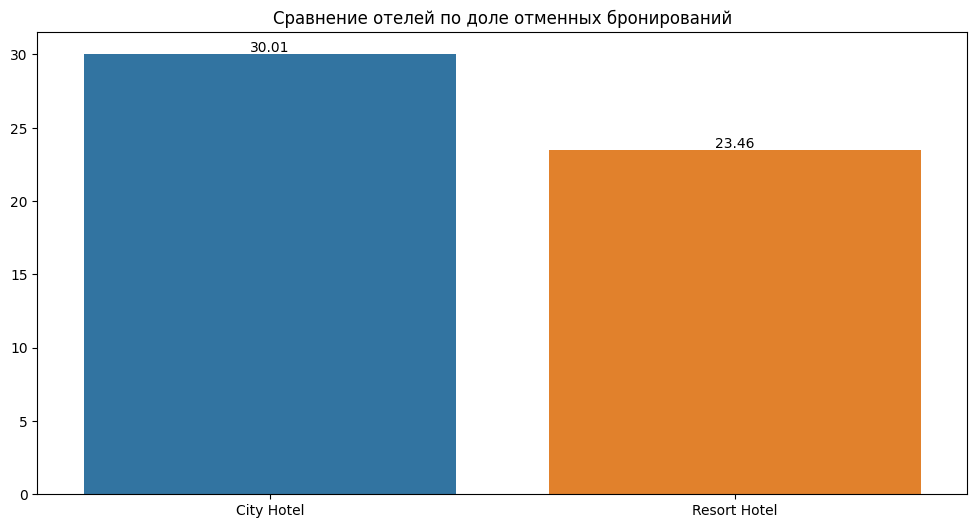

In [54]:
plt.figure(figsize=(12,6))
plt.title('Сравнение отелей по доле отменных бронирований')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot
ax = sns.barplot(pd.DataFrame({'City Hotel': [city_hotel_canceled_cnt], 'Resort Hotel': [resort_hotel_canceled_cnt]}))
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

В City Hotel доля отмененных бронирований больше, 30.01% против 23.46%. То есть на первый взгляд Resort Hotel показывает себя лучше, но мы еще далее посмотрим сравнение этих отелей вкупе с другими признаками.

### guests_categories & is_canceled

Посмотрим на то, есть ли различия между разными типами гостей и таргетом

In [55]:
guests_categories = df.groupby('guests_categories').agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))

guests_categories['canceled_pct'] = round(guests_categories['total_canceled'] / guests_categories['total_rows'] * 100, 2)
guests_categories = guests_categories.sort_values('canceled_pct', ascending=False)

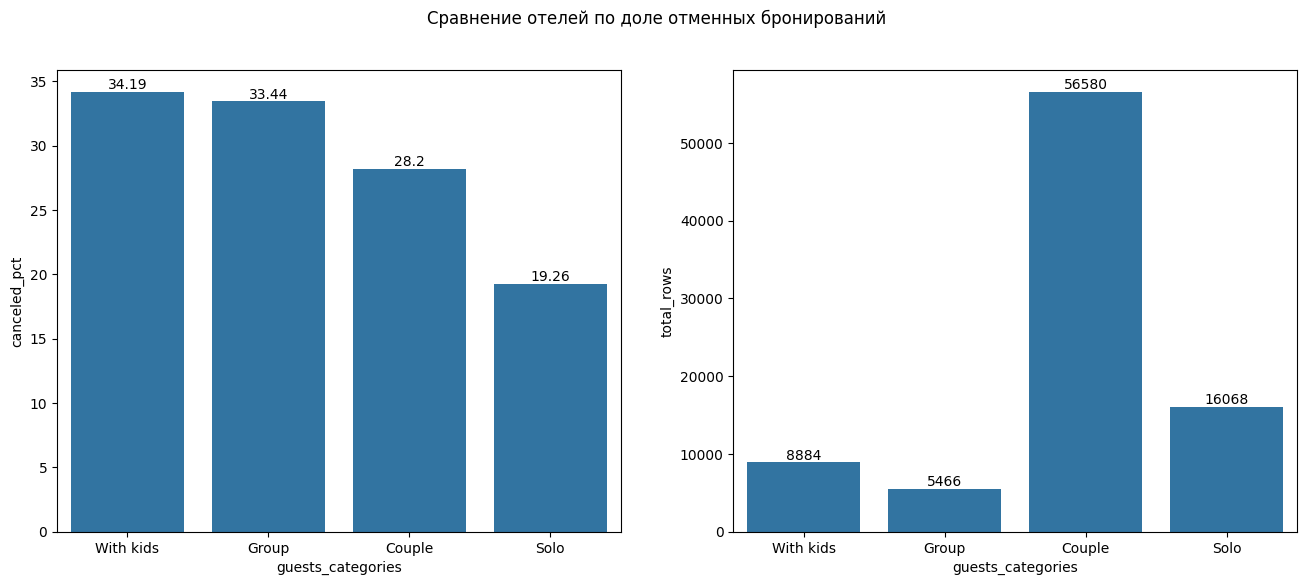

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение отелей по доле отменных бронирований')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot + добавили объектный подход построения нескольких графиков на полотне
sns.barplot(guests_categories['canceled_pct'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(guests_categories['total_rows'], ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

Можно заметить, что самая высокая доля отмен у броней только с детьми в виде гостей, но их и самое малое количество. Интереснее тут группы: 1) с одним гостем и 2) гости с детьми. Сольные брони у нас самые успешные по таргету, а с детьми самые неуспешные, не считая очень маленькой "странной" группы - только дети. При этом размеры выборок обе сильно меньше самой популярной группы - пары и между собой не так сильно различимы, хоть и разница примерно в 2 раза по размерам. Так что эту гипотезу можно далее проверить статистически - действительно ли брони с детьми "хуже" сольных бронирований.

### Объединим два наблюдения выше. Посмотрим также сравнение категорий гостей, но дополнительно сравним разные отели

In [57]:
guests_categories = df.groupby(['guests_categories', 'hotel']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))

guests_categories['canceled_pct'] = round(guests_categories['total_canceled'] / guests_categories['total_rows'] * 100, 2)
guests_categories = guests_categories.sort_values('canceled_pct', ascending=False)

In [58]:
guests_categories

total_canceled  total_rows  canceled_pct
guests_categories hotel                                                 
Group             City Hotel              1643        4452         36.90
With kids         Resort Hotel            1364        3869         35.25
                  City Hotel              1673        5015         33.36
Couple            City Hotel             10375       33412         31.05
                  Resort Hotel            5582       23168         24.09
Solo              City Hotel              2262       10175         22.23
Group             Resort Hotel             185        1014         18.24
Solo              Resort Hotel             832        5893         14.12

In [59]:
hotels_value_counts = df['hotel'].value_counts().reset_index().T
# https://datascientyst.com/how-to-use-the-first-row-as-the-header-in-pandas/
hotels_value_counts.columns = hotels_value_counts.iloc[0]
hotels_value_counts = hotels_value_counts[1:]

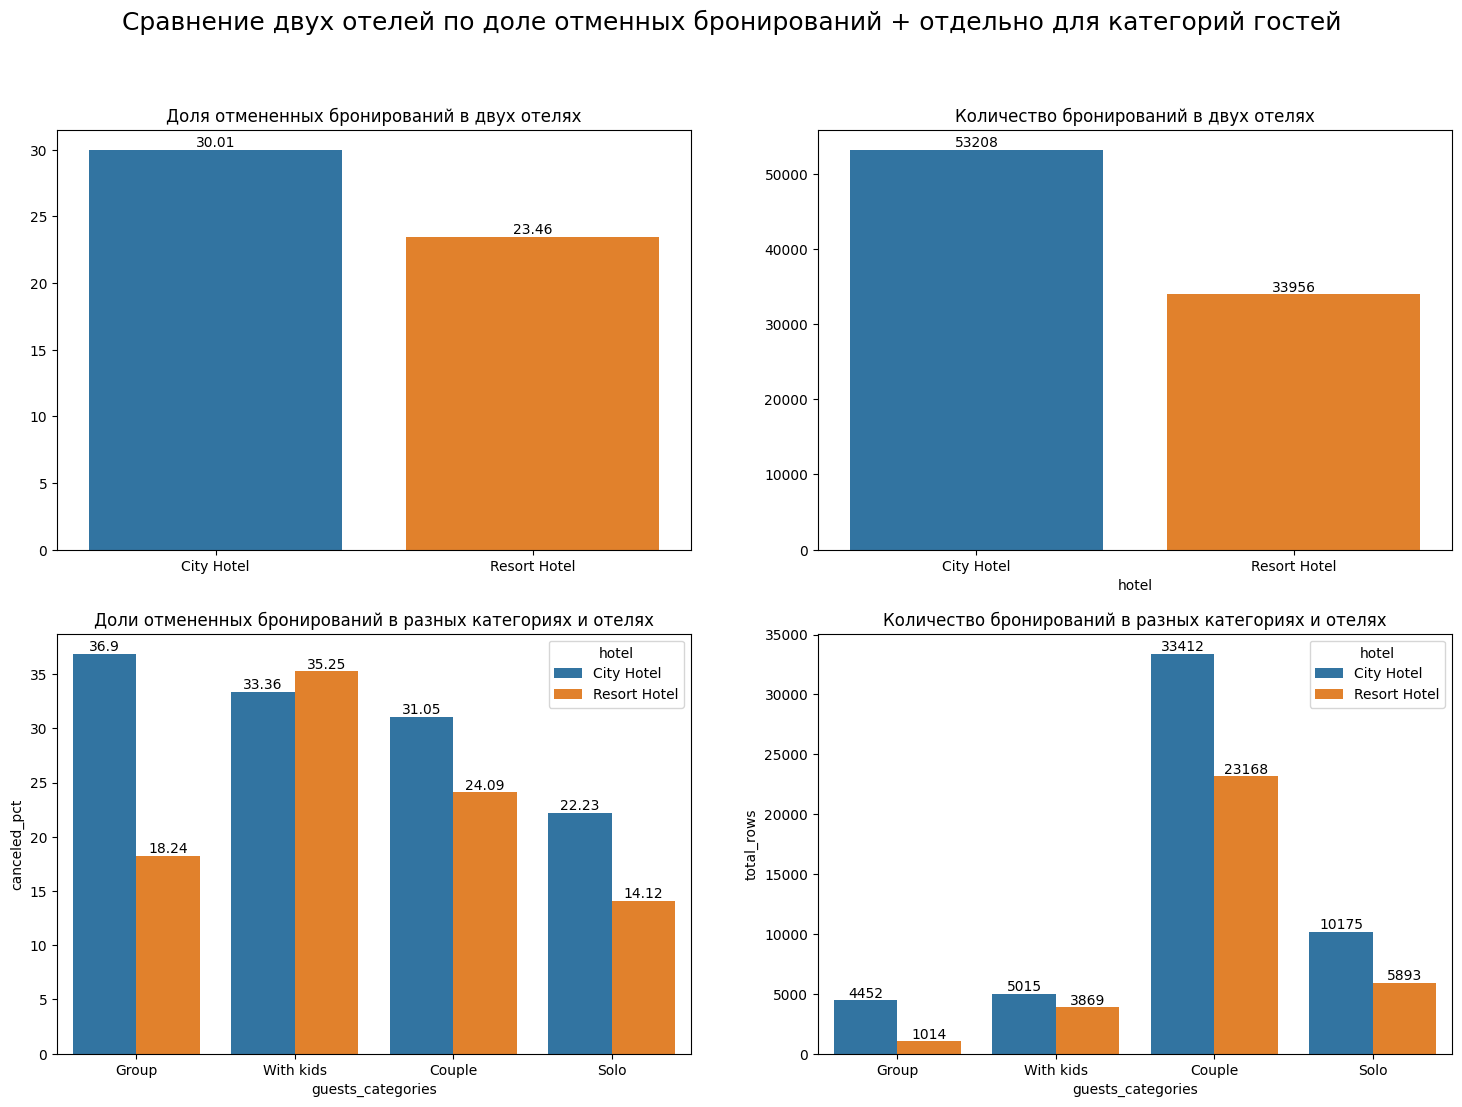

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.suptitle('Сравнение двух отелей по доле отменных бронирований + отдельно для категорий гостей', fontsize='18')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot + добавили объектный подход построения нескольких графиков на полотне

sns.barplot(pd.DataFrame({'City Hotel': [city_hotel_canceled_cnt], 'Resort Hotel': [resort_hotel_canceled_cnt]}), ax=axes[0, 0])
axes[0, 0].set_title('Доля отмененных бронирований в двух отелях')
axes[0, 0].bar_label(axes[0, 0].containers[0])
axes[0, 0].bar_label(axes[0, 0].containers[1])

sns.barplot(hotels_value_counts, ax=axes[0, 1])
axes[0, 1].set_title('Количество бронирований в двух отелях')
axes[0, 1].bar_label(axes[0, 1].containers[0])
axes[0, 1].bar_label(axes[0, 1].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='canceled_pct', hue='hotel', ax=axes[1, 0])
axes[1, 0].set_title('Доли отмененных бронирований в разных категориях и отелях')
axes[1, 0].bar_label(axes[1, 0].containers[0])
axes[1, 0].bar_label(axes[1, 0].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='total_rows', hue='hotel', ax=axes[1, 1])
axes[1, 1].set_title('Количество бронирований в разных категориях и отелях')
axes[1, 1].bar_label(axes[1, 1].containers[0])
axes[1, 1].bar_label(axes[1, 1].containers[1])
plt.show()

Тут добавилось интересное дополнение - категория With kids в обоих отелях примерно с одинаковой долей отмененных броней и с несильно отличающейся выборкой в каждом из отелей, а вот если смотреть на Solo, то в Resort Hotel она показывает себя еще лучше с процентом отмен всего в 14.12%, но бронирований там почти в 2 раза меньше чем в City Hotel. Отсюда выходит еще одна возможная гипотеза о том, что Solo успешнее, причем в одном из отелей, который в целом по всем категориям показывает себя лучше - это еще заметнее и тогда сравнение этих категорий в рамках Resort Hotel, возможно, покажет еще большую уверенность и саму разность групп. Анализ всего этого блока может в итоге дать хорошее наблюдение для отеля - а именно то, какие категории гостей надежнее и в каких отелях это проявляется особенно хорошо или же один отель просто в целом лучше другого и разница между категориями внутри отелей примерно одинаковая. Далее надо подумать над тем, какие гипотезы сформировать лучше всего для получения наиболее полезного результата для бизнеса.

#### guests_categories & (market_segment, distribution_channel)
Посмотрим на то, как об отеле узнают, как бронируют разные категории гостей. Только в этот раз не будем смотреть категории Only kids чтобы не перезагружать полученный "дашборд".

In [61]:
market_segment_in_guests_categories = df.groupby(['guests_categories', 'market_segment']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size')).reset_index()
market_segment_in_guests_categories['canceled_pct'] = round(market_segment_in_guests_categories['total_canceled'] / market_segment_in_guests_categories['total_rows'] * 100, 2)

distribution_channel_in_guests_categories = df.groupby(['guests_categories', 'distribution_channel']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size')).reset_index()
distribution_channel_in_guests_categories['canceled_pct'] = round(distribution_channel_in_guests_categories['total_canceled'] / distribution_channel_in_guests_categories['total_rows'] * 100, 2)

distribution_channel_in_guests_categories


,guests_categories,distribution_channel,total_canceled,total_rows,canceled_pct
0,Couple,Corporate,227,1157,19.62
1,Couple,Direct,1181,7844,15.06
2,Couple,Other,8,17,47.06
3,Couple,TA/TO,14541,47562,30.57
4,Group,Corporate,9,61,14.75
5,Group,Direct,93,612,15.20
6,Group,Other,2,2,100.00
7,Group,TA/TO,1724,4791,35.98
8,Solo,Corporate,405,3788,10.69
9,Solo,Direct,352,2684,13.11


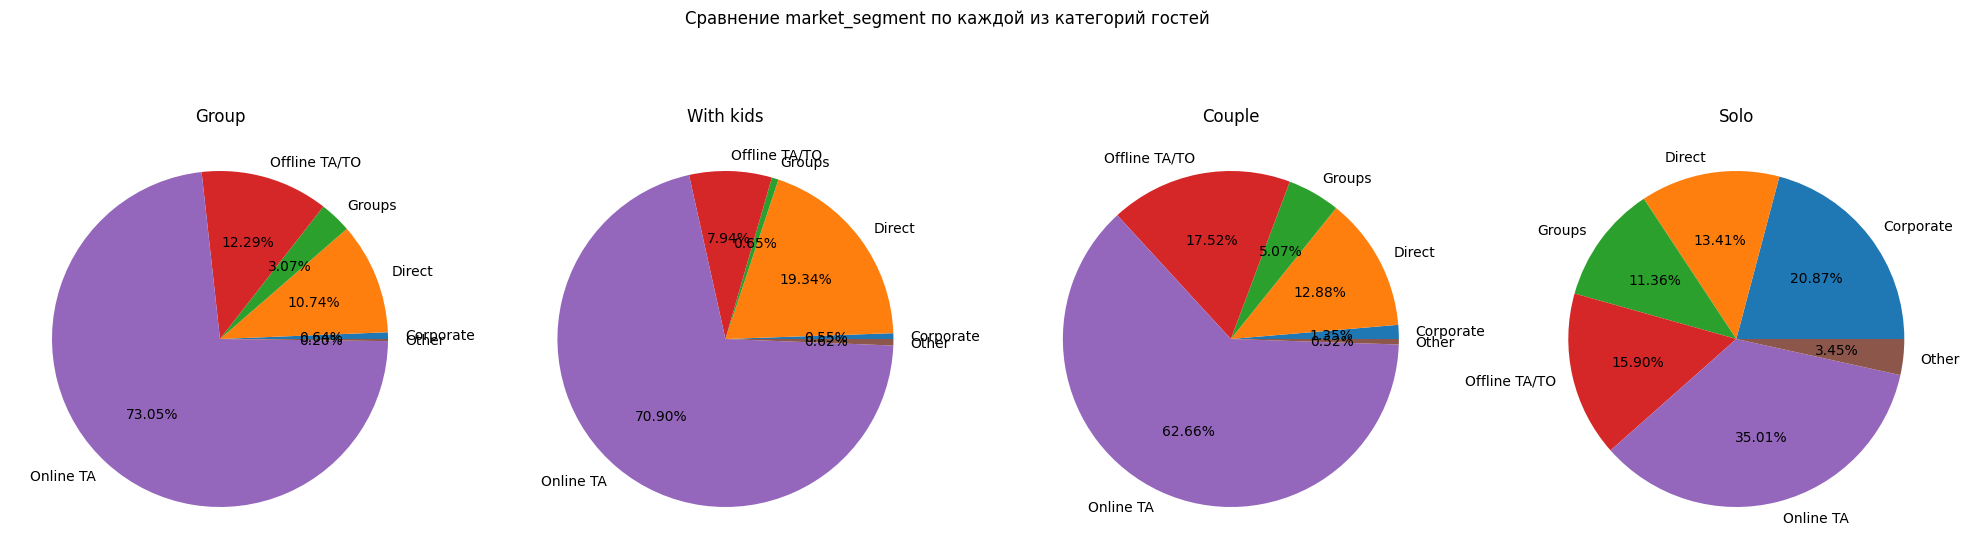

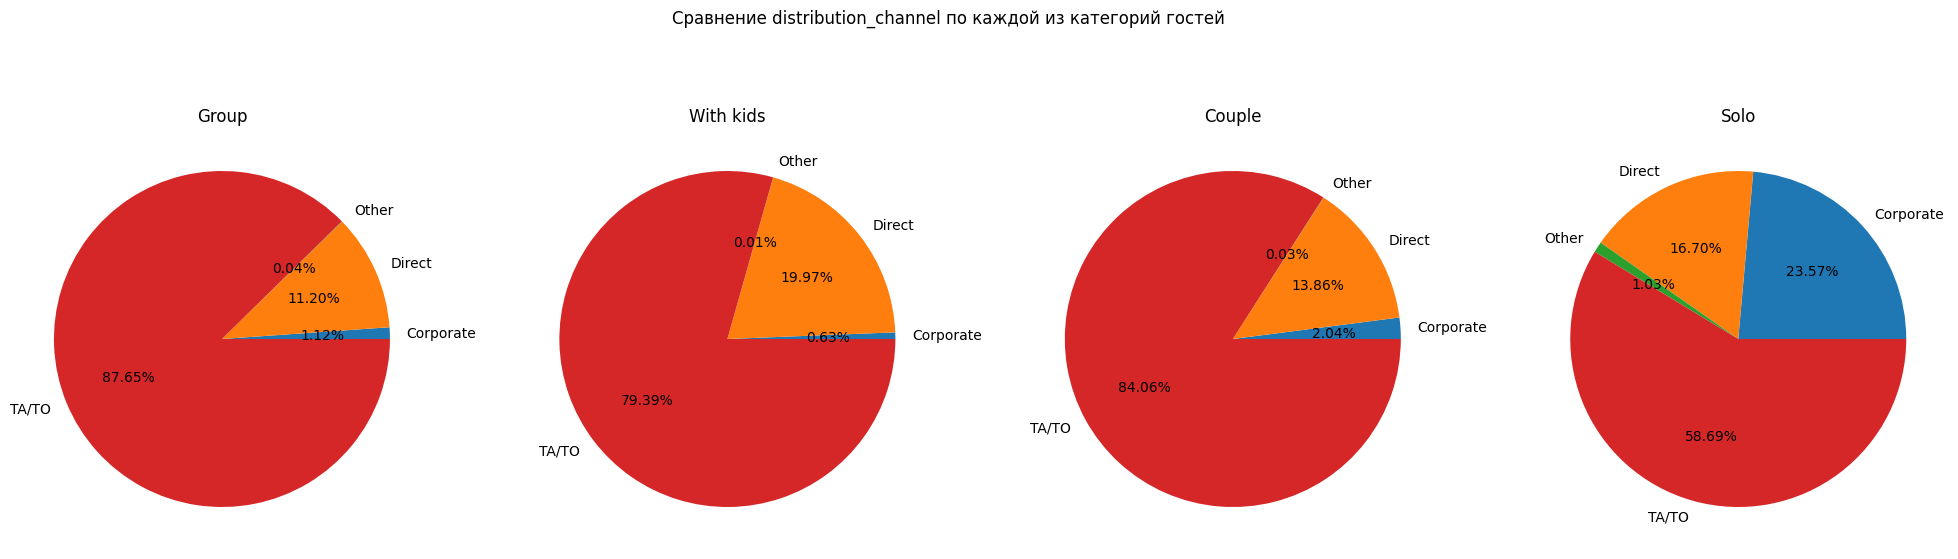

In [62]:
plt.figure(figsize=(25, 12))

plt.suptitle('Сравнение market_segment по каждой из категорий гостей')
plt.subplot(2, 4, 1)

plt.title('Group')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'Group']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 2)

plt.title('With kids')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'With kids']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 3)

plt.title('Couple')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'Couple']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 4)

plt.title('Solo')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'Solo']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.show()

plt.figure(figsize=(25, 12))

plt.suptitle('Сравнение distribution_channel по каждой из категорий гостей')
plt.subplot(2, 4, 1)

plt.title('Group')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'Group']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 2)

plt.title('With kids')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'With kids']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 3)

plt.title('Couple')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'Couple']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 4)

plt.title('Solo')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'Solo']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.show()

Можно заметить, что во всех категориях кроме Solo большая часть бронирований оформляется через тур агентов и тур операторов, причем зачастую онлайн. Но вот у Solo заметно увеличение как категории Corporate, что как будто говорит о том, что это оформляются командировочные для сотрудников, так и Groups, что как будто также говорит о том, что это те же командировки, но групповые. Это предположительно может объяснять низкую долю отмен бронирований, но для этого давайте далее сравним Corporate с другими (возьмем самые основные: TO/TA и Direct) по таргету is_canceled. Пока продолжим смотреть по обоим признакам и по market_segment и по distribution_channel.

In [63]:
market_segments = df.groupby('market_segment').agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))
market_segments['canceled_pct'] = round(market_segments['total_canceled'] / market_segments['total_rows'] * 100, 2)
market_segments = market_segments[market_segments.index != 'Other']

distribution_channels = df.groupby('distribution_channel').agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))
distribution_channels['canceled_pct'] = round(distribution_channels['total_canceled'] / distribution_channels['total_rows'] * 100, 2)
distribution_channels = distribution_channels[distribution_channels.index != 'Other']

distribution_channels


,total_canceled,total_rows,canceled_pct
distribution_channel,,,
Corporate,648,5081,12.75
Direct,1911,12948,14.76
TA/TO,21333,68949,30.94


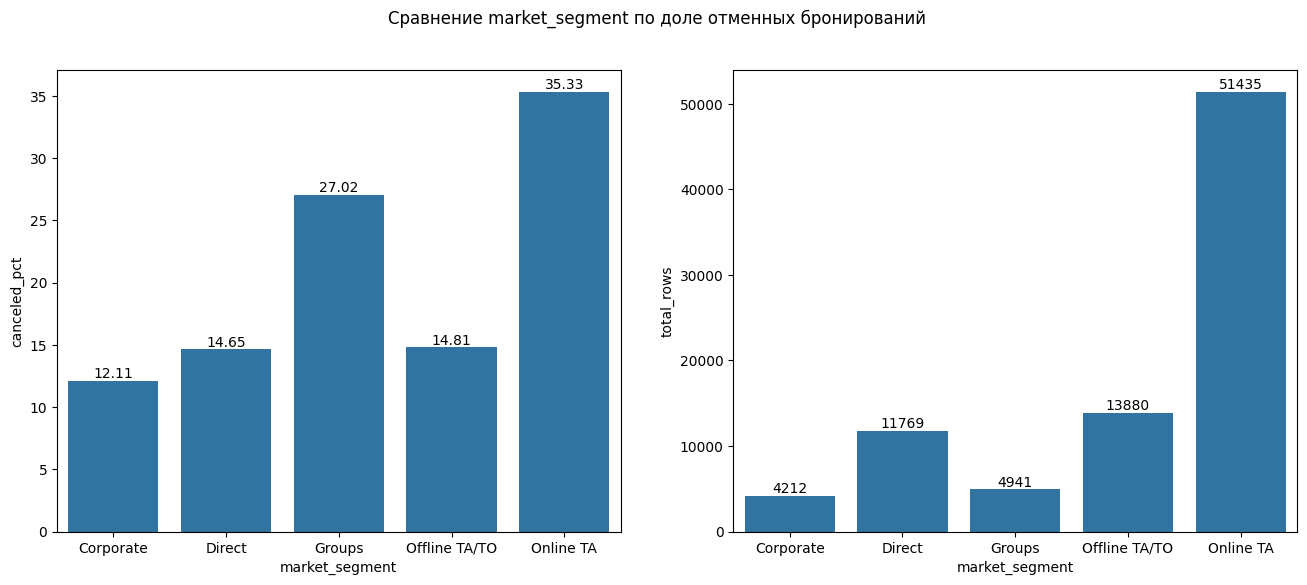

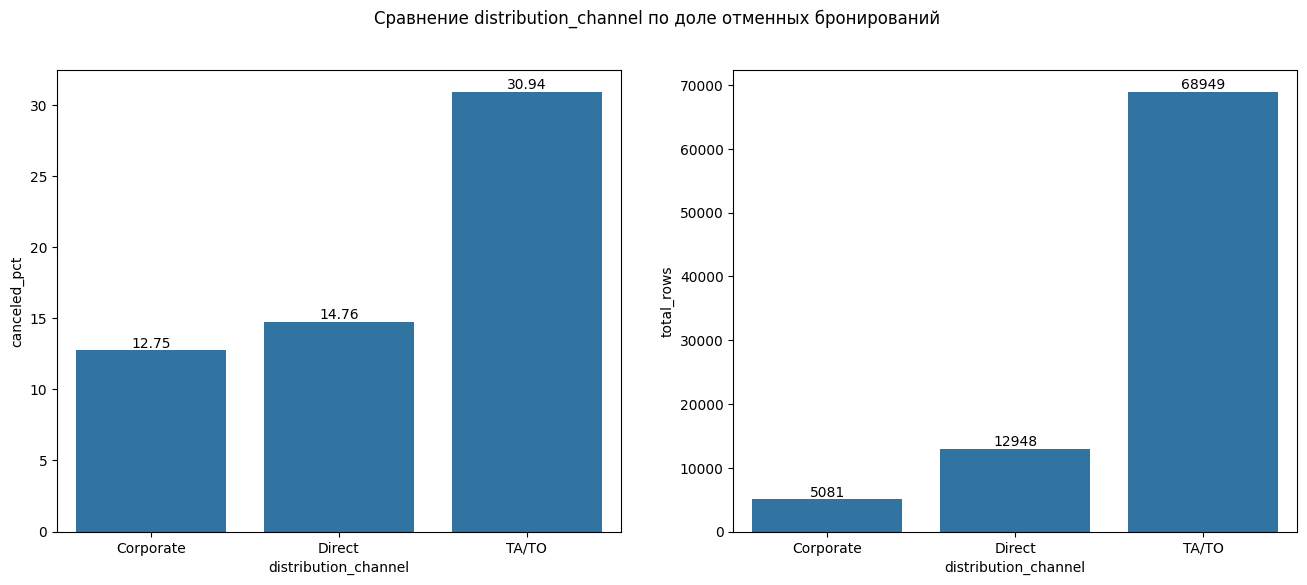

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение market_segment по доле отменных бронирований')

sns.barplot(market_segments['canceled_pct'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(market_segments['total_rows'], ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение distribution_channel по доле отменных бронирований')

sns.barplot(distribution_channels['canceled_pct'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(distribution_channels['total_rows'], ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

Действительно, у Corporate ниже доля отмен, вот как раз таки у TA/TO сильно выше, но пока статистически это не подтверждено.

И давайте на этом моменте далее будем проводить анализ используя только признак market_segment, потому что он содержить чуть более подробную информацию о разных сегментах, а совмещая их значения выходит почти как у distribution_channel.

Теперь давайте закрепим наше первичное представление о причина успеха Solo и вернемся к графикам с прошлой части анализа но посмотрим все только без Corporate, то есть попробуем так уровнять Solo с другими категориями гостей.

Для начала все используемые датафреймы отфильтруем по новому условию

In [65]:
df_without_corp = df[(df['market_segment'] != 'Corporate') & (df['distribution_channel'] != 'Corporate')]
city_hotel_canceled_cnt = round(df_without_corp[(df_without_corp['hotel'] == 'City Hotel') & (df_without_corp['is_canceled'] == 1)].shape[0] / df_without_corp[df_without_corp['hotel'] == 'City Hotel'].shape[0] * 100, 2)
resort_hotel_canceled_cnt = round(df_without_corp[(df_without_corp['hotel'] == 'Resort Hotel') & (df_without_corp['is_canceled'] == 1)].shape[0] / df_without_corp[df_without_corp['hotel'] == 'Resort Hotel'].shape[0] * 100, 2)

guests_categories = df_without_corp.groupby(['guests_categories', 'hotel']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))

guests_categories['canceled_pct'] = round(guests_categories['total_canceled'] / guests_categories['total_rows'] * 100, 2)
guests_categories = guests_categories.sort_values('canceled_pct', ascending=False)

hotels_value_counts = df_without_corp['hotel'].value_counts().reset_index().T
# https://datascientyst.com/how-to-use-the-first-row-as-the-header-in-pandas/
hotels_value_counts.columns = hotels_value_counts.iloc[0]
hotels_value_counts = hotels_value_counts[1:]

In [66]:
df_without_corp

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,customer_type,adr,total_of_special_requests,stays_in_nights,has_weekend_nights,guests_categories
0,Resort Hotel,0,342,2015,July,1,PRT,Direct,Direct,0,0,>2,No Deposit,Transient,0.00,0,0,0,Couple
1,Resort Hotel,0,737,2015,July,1,PRT,Direct,Direct,0,0,>2,No Deposit,Transient,0.00,0,0,0,Couple
2,Resort Hotel,0,7,2015,July,1,GBR,Direct,Direct,0,0,0,No Deposit,Transient,75.00,0,1,0,Solo
4,Resort Hotel,0,14,2015,July,1,GBR,Online TA,TA/TO,0,0,0,No Deposit,Transient,98.00,1,2,0,Couple
5,Resort Hotel,0,0,2015,July,1,PRT,Direct,Direct,0,0,0,No Deposit,Transient,107.00,0,2,0,Couple
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87159,City Hotel,0,23,2017,August,30,BEL,Offline TA/TO,TA/TO,0,0,0,No Deposit,Transient,96.14,0,7,1,Couple
87160,City Hotel,0,102,2017,August,31,FRA,Online TA,TA/TO,0,0,0,No Deposit,Transient,225.43,2,7,1,Group
87161,City Hotel,0,34,2017,August,31,DEU,Online TA,TA/TO,0,0,0,No Deposit,Transient,157.71,>2,7,1,Couple
87162,City Hotel,0,109,2017,August,31,GBR,Online TA,TA/TO,0,0,0,No Deposit,Transient,104.40,0,7,1,Couple


А далее построим тот же график.

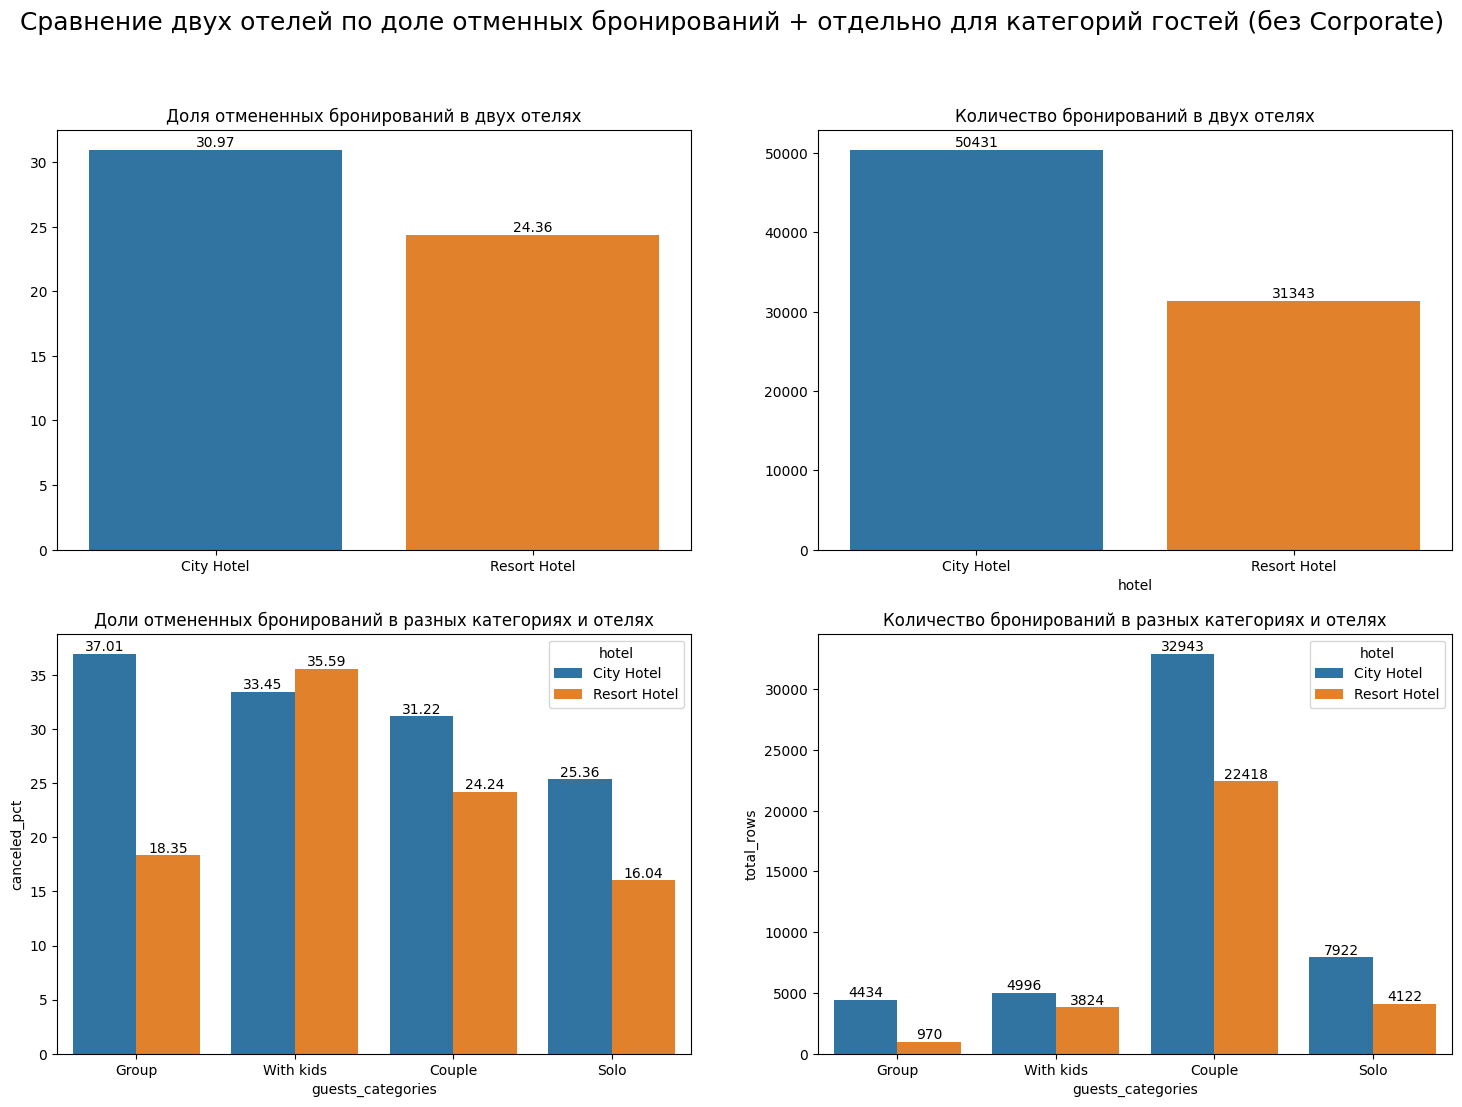

In [67]:


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.suptitle('Сравнение двух отелей по доле отменных бронирований + отдельно для категорий гостей (без Corporate)', fontsize='18')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot + добавили объектный подход построения нескольких графиков на полотне

sns.barplot(pd.DataFrame({'City Hotel': [city_hotel_canceled_cnt], 'Resort Hotel': [resort_hotel_canceled_cnt]}), ax=axes[0, 0])
axes[0, 0].set_title('Доля отмененных бронирований в двух отелях')
axes[0, 0].bar_label(axes[0, 0].containers[0])
axes[0, 0].bar_label(axes[0, 0].containers[1])

sns.barplot(hotels_value_counts, ax=axes[0, 1])
axes[0, 1].set_title('Количество бронирований в двух отелях')
axes[0, 1].bar_label(axes[0, 1].containers[0])
axes[0, 1].bar_label(axes[0, 1].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='canceled_pct', hue='hotel', ax=axes[1, 0])
axes[1, 0].set_title('Доли отмененных бронирований в разных категориях и отелях')
axes[1, 0].bar_label(axes[1, 0].containers[0])
axes[1, 0].bar_label(axes[1, 0].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='total_rows', hue='hotel', ax=axes[1, 1])
axes[1, 1].set_title('Количество бронирований в разных категориях и отелях')
axes[1, 1].bar_label(axes[1, 1].containers[0])
axes[1, 1].bar_label(axes[1, 1].containers[1])
plt.show()

Вывыдем отдельно еще данные с прошлого графика:

In [94]:
print(f'Доля отмененных бронирований в Resort Hotel: 24.36% (23.46% - без Corporate)')
print(f'Доля отмененных бронирований в Resort Hotel для Solo: 16.04% (14.12% - без Corporate)\n')

print(f'Доля отмененных бронирований в City Hotel: 30.97% (30.01% - без Corporate)')
print(f'Доля отмененных бронирований в City Hotel для Solo: 25.36% (22.23% - без Corporate)')

Доля отмененных бронирований в Resort Hotel: 24.36% (23.46% - без Corporate)
Доля отмененных бронирований в Resort Hotel для Solo: 16.04% (14.12% - без Corporate)

Доля отмененных бронирований в City Hotel: 30.97% (30.01% - без Corporate)
Доля отмененных бронирований в City Hotel для Solo: 25.36% (22.23% - без Corporate)


В Resort Hotel с новым фильтром доля отменных бронирований выросла, но также произошла и для City Hotel, так что на первый взгляд говорить, что Corporate "завышвает" результаты для Resort Hotel нельзя, но можно сказать, что сказывается отдельно на категории Solo, хотя даже так она сильно лучше остальных, о чем мы говорили по прошлому графику

### adr & guests_categories

Посмотрим теперь на то, какие средние чеки фиксируются для наших категорий гостей. Это поможет нам смотреть на категорию не только с точки зрения успешности по основному таргету - не отменяется ли бронь, а и с точки зрения денежной выгоды. Возможно, найдем потенциально прибыльные категории гостей, над удержанием броней которых стоит поработать.

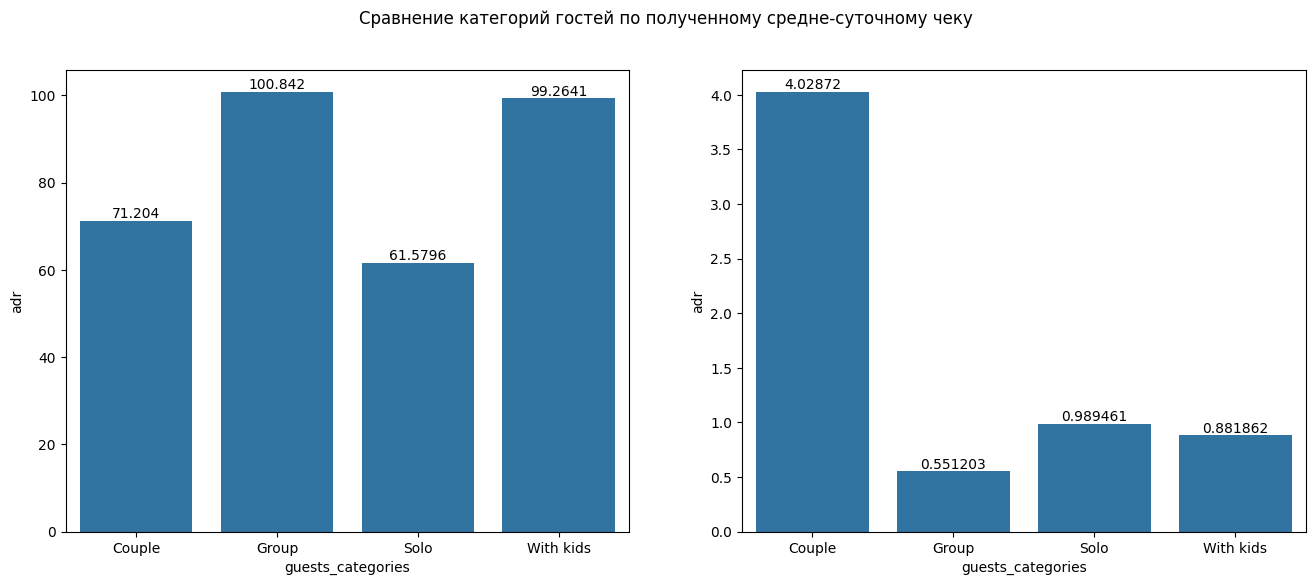

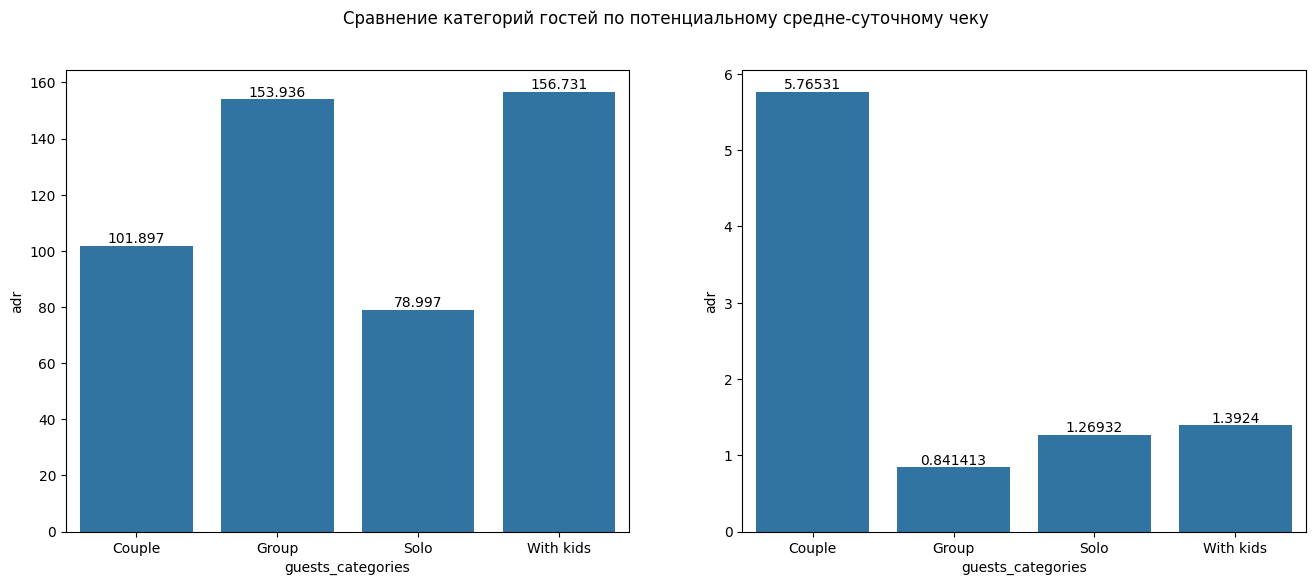

In [69]:
df_new_adr = df.copy()
df_new_adr.loc[df_new_adr['is_canceled'] == 1, 'adr'] = 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение категорий гостей по полученному средне-суточному чеку')

sns.barplot(df_new_adr.groupby('guests_categories')['adr'].mean(), ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(df_new_adr.groupby('guests_categories')['adr'].sum() / 1000000, ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение категорий гостей по потенциальному средне-суточному чеку')

sns.barplot(df.groupby('guests_categories')['adr'].mean(), ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(df.groupby('guests_categories')['adr'].sum() / 1000000, ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

Конечно же, сравнивать категории не по чистой прибыли, а по общей выручке некорректно, но что мы можем сейчас заметить: у Couple, из-за большей доли бронирований - общая выручка по этому показателю сильно выше чем у других, причем если мы посмотрим на те же графики но с учетом потенциала (то есть не будем обнулять adr для отмененных бронирований), то мы теряем сумму полученную с Solo и With kids вместе взятых. И если мы посмотрим сравнение ее и Solo, т.к. Solo пока по is_canceled выглядит успешнее всего и количество гостей с Couple не сильно отличается, то по текущим показателям средний чек для нее всего на +-16% выше, хотя гостей там двое. Это может стать сигналом о том, что на Couple, из-за общего объема бронирований, необходимо обратить внимание и в первую очередь минимизировать отмены там, так как популярность этой категории это не только в особенности отелей, но и в общей популярности отелей среди пар. 

### lead_time & is_canceled

Посмотрим также на то, как степень того, насколько заранее бронь была офорлена - влияет на возможную ее отмену.

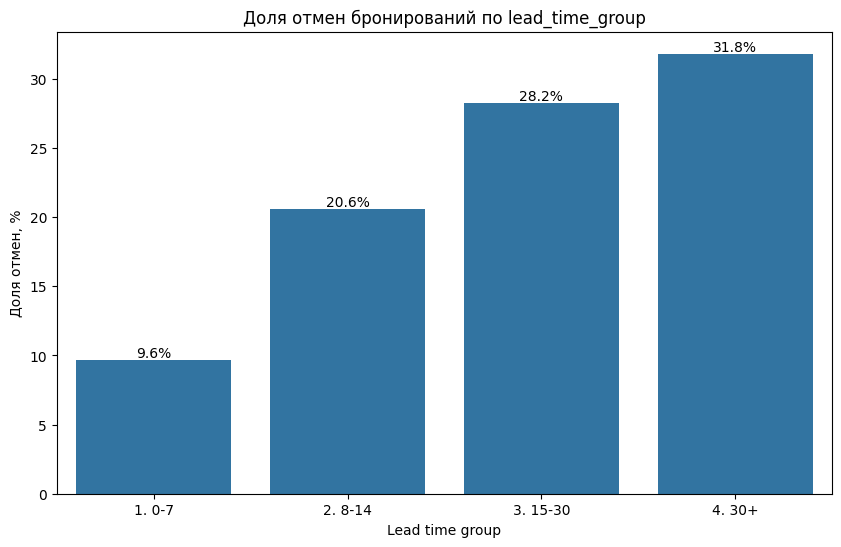

In [70]:
df_lead_time = df.copy()

def lead_time_group(x):
    if x['lead_time'] > 0 and x['lead_time'] <= 7:
        return '1. 0-7'
    elif x['lead_time'] > 7 and x['lead_time'] <= 14:
        return '2. 8-14'
    elif x['lead_time'] > 14 and x['lead_time'] <= 30:
        return '3. 15-30'
    else:
        return '4. 30+'

df_lead_time['lead_time_group'] = df_lead_time.apply(lead_time_group, axis=1)
lead_time_cancel_rate = df_lead_time.groupby('lead_time_group')['is_canceled'].mean() * 100

plt.figure(figsize=(10, 6))

plt.title('Доля отмен бронирований по lead_time_group')

sns.barplot(lead_time_cancel_rate)

plt.xlabel('Lead time group')
plt.ylabel('Доля отмен, %')

plt.bar_label(plt.gca().containers[0], fmt='%.1f%%')

plt.show()

## Сформулируем и проверим гипотезы

Далее для всех гипотез сразу зафиксируем уровень значимости (альфа) как 5%.

### Для начала проверим простую гипотезу о том, что разница между отелями действительно есть, а именно, что доля отмен в City Hotel была выше, что вытекает еще из первого графика

#### H0: доля отмененных бронирований у City Hotel не выше чем у Resort hotel

#### H1: доля отмененных бронирований у City Hotel выше чем у Resort hotel

У нас даны две доли отмен для City Hotel и Resort Hotel и мы хотим посмотреть есть ли статистическая разница между ними. Для этого мы можем использовать z-test для двух долей (в котором мы можем отдельно посмотреть как раз таки наш односторонний случай), который смотри на их различие между двумя независимыми группами. У нас один отель не может быть и City и Resort, так что группы независимы. is_canceled как раз может использоваться для расчета долей (что мы и строили на графике) - т.е. доля "успеха" (у нас наоборот - отмена) для каждого отеля. Также количество наблюдений и значений каждой из групп у нас более чем большое, напомним какие значения мы увидели из графиков:


In [71]:
city_hotel_canceled = df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 1)].shape[0]
resort_hotel_canceled = df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 1)].shape[0]

city_hotel_shape0 = df[df['hotel'] == 'City Hotel'].shape[0]
resort_hotel_shape0 = df[df['hotel'] == 'Resort Hotel'].shape[0]

In [72]:
print(f'City Hotel: {city_hotel_canceled / city_hotel_shape0 * 100}%')
print(f'Resort Hotel: {resort_hotel_canceled / resort_hotel_shape0 * 100}%')

City Hotel: 30.00864531649376%
Resort Hotel: 23.45682648132878%


In [73]:
# https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html
from statsmodels.stats.proportion import proportions_ztest
count = np.array([city_hotel_canceled, resort_hotel_canceled])
nobs = np.array([city_hotel_shape0, resort_hotel_shape0])
stat, pval = proportions_ztest(count, nobs, alternative='larger')
print(pval)

1.8630497204482852e-99


p_value < 0.05, значит у нас есть основания отвергать нулевую гипотезу и принять первую, т.е. доля отменных бронирований у City Hotel выше чем у Resort hotel

Это может дать нам общий вывод о том, что City Hotel в целом хуже реализует бронирования, что должно стать поводом разобраться с тем, с чем у City Hotel проблемы.

### Далее проверим, есть ли у нас различия между разными категориями в market_segment (откуда бронируются отели), а именно зависит ли отмена бронирования от market_segment

#### H0: факт отмены бронирования не зависит от market_segment

#### H1: факт отмены бронирования зависит от market_segment

Здесь применим будет хи-квадрат Пирсона, через построение таблицы сопряженности. Это подходит т.к. market_segment и is_canceled - это категориальные признаки, при этом is_canceled бинарный, а market_segment - нет + выборки у нас довольно большие, можем еще раз посмотреть на количество наблюдений в каждой из категорий:

In [74]:
df['market_segment'].value_counts()

market_segment
Online TA        51435
Offline TA/TO    13880
Direct           11769
Groups            4941
Corporate         4212
Other              927
Name: count, dtype: int64

In [75]:
from scipy.stats import chi2_contingency

# Для начала надо построить таблицу сопряженности - https://stackoverflow.com/questions/52679863/creating-a-contingency-table-in-pandas
c_table = pd.crosstab(df['market_segment'], df['is_canceled'])
chi2_contingency(c_table)

Chi2ContingencyResult(statistic=np.float64(4262.2911397462985), pvalue=np.float64(0.0), dof=5, expected_freq=array([[ 3055.54109495,  1156.45890505],
       [ 8537.66931302,  3231.33068698],
       [ 3584.384746  ,  1356.615254  ],
       [10069.06704603,  3810.93295397],
       [37312.85760176, 14122.14239824],
       [  672.48019825,   254.51980175]]))

In [76]:
print(f'p_value = {chi2_contingency(c_table)[1]}')

p_value = 0.0


p_value < 0.05, а значит мы имеем основания отвергнуть нулевую гипотезу и принимаем первую гипотезу => факт отмены бронирования зависит от market_segment

Пока, в таком размытом сравнении тяжело сказать в чем именно есть явные проблемы и на какой сегмент в первую очередь обратить внимание, поэтому, опираясь на построенные визуализации выше, посмотрим конкретно для категории Online TA - где мы наблюдали самую высокую долю отмен.

Посмотрим, действительно ли брони с Online TA у нас отменяются чаще, чем остальные.

#### H0: доля отмен бронирований с Online TA не выше чем у остальных сегментов.

#### H1: доля отмен бронирований с Online TA выше чем у остальных сегментов.

Аналогично гипотезе с сравнением отелей - применим z-тест.

In [77]:
online_ta_market_segment_canceled = df[(df['market_segment'] == 'Online TA') & (df['is_canceled'] == 1)].shape[0]
other_market_segment_canceled = df[(df['market_segment'] != 'Online TA') & (df['is_canceled'] == 1)].shape[0]

online_ta_market_segment_shape0 = df[df['market_segment'] == 'Online TA'].shape[0]
other_market_segment_shape0 = df[df['market_segment'] != 'Online TA'].shape[0]

# https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html
from statsmodels.stats.proportion import proportions_ztest
count = np.array([online_ta_market_segment_canceled, other_market_segment_canceled])
nobs = np.array([online_ta_market_segment_shape0, other_market_segment_shape0])
stat, pval = proportions_ztest(count, nobs, alternative='larger')
print(pval)

0.0


p_value < 0.05, а значит мы имеем основания отвергнуть нулевую гипотезу и принимаем первую гипотезу => доля отмен бронирований с Online TA выше чем у остальных сегментов.

Это сигнал бизнесу о том, что с этим сегметом явные проблемы, они приводят клиентов, которые в итоге к нам не приезжают, что негативно сказывается на успехе отелей.

### Далее, аналогично проверке различия market_segment, проверим, есть ли у нас различия между разными категориями гостей в guests_categories.

#### H0: факт отмены бронирования не зависит от guests_categories

#### H1: факт отмены бронирования зависит от guests_categories

Здесь применим будет тот же хи-квадрат Пирсона, через построение таблицы сопряженности, что и был у market_segment, т.к. guests_categories также категориальный признак с большими выборками у каждых категорий.

In [78]:
df['guests_categories'].value_counts()

guests_categories
Couple       56580
Solo         16068
With kids     8884
Group         5466
Name: count, dtype: int64

In [79]:
from scipy.stats import chi2_contingency

c_table = pd.crosstab(df['guests_categories'], df['is_canceled'])
chi2_contingency(c_table)

Chi2ContingencyResult(statistic=np.float64(857.9346511876157), pvalue=np.float64(1.177687514895565e-185), dof=3, expected_freq=array([[41025.99554013, 15554.00445987],
       [ 3963.38090531,  1502.61909469],
       [11650.86066346,  4417.13933654],
       [ 6441.7628911 ,  2442.2371089 ]]))

In [80]:
print(f'p_value = {chi2_contingency(c_table)[1]}')

p_value = 1.177687514895565e-185


p_value < 0.05, а значит мы имеем основания отвергнуть нулевую гипотезу и принимаем первую гипотезу => факт отмены бронирования зависит от guests_categories

Теперь также, убедившись, что категории различаются - перейдем к проверке различия какой-то определенной категории. А именно, давайте проверим, действительно ли одичные бронивания (Solo) отменяются реже, что мы наблюдали во время построения визуализаций раннее.

#### H0: доля отмен для одиночных бронирований не ниже чем у остальных категорий гостей.

#### H1: доля отмен для одиночных бронирований ниже чем у остальных категорий гостей.

Применим аналогично z-test, но тут уже будем в параметре alternative укажем smaller, т.к. теперь мы смотрим действительно ли **ниже** доля отмен у Solo.

In [81]:
solo_guests_categories_canceled = df[(df['guests_categories'] == 'Solo') & (df['is_canceled'] == 1)].shape[0]
other_guests_categories_canceled = df[(df['guests_categories'] != 'Solo') & (df['is_canceled'] == 1)].shape[0]

solo_guests_categories_shape0 = df[df['guests_categories'] == 'Solo'].shape[0]
other_guests_categories_shape0 = df[df['guests_categories'] != 'Solo'].shape[0]

# https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html
from statsmodels.stats.proportion import proportions_ztest
count = np.array([solo_guests_categories_canceled, other_guests_categories_canceled])
nobs = np.array([solo_guests_categories_shape0, other_guests_categories_shape0])
stat, pval = proportions_ztest(count, nobs, alternative='smaller')
print(pval)

5.724997027940906e-147


p_value < 0.05, а значит мы имеем основания отвергнуть нулевую гипотезу и принимаем первую гипотезу => доля отмен для одиночных бронирований ниже чем у остальных категорий гостей.

У нас подтвреждается успех категории Solo, а значит для этой категории отели работают лучше чем остальные, тут вопрос либо в том, чтобы усилять долю этих бронирований, либо стараться уровнять ее с остальными категориями, которых тоже немало встречается среди бронирований.

### Далее, сформулируем еще одну гипотезу о adr с таргетом

H0: Распределение средней стоимости бронирования не отличается между отмененными и неотмененными бронированиями

H1: Распределение средней стоимости бронирования отличается между отмененными и неотмененными бронированиями

Для начала надо подготовить 2 группы 

In [82]:
adr_1 = df[df['is_canceled'] == 1]['adr'] #фильтруем и берем adr этих значений
adr_0 = df[df['is_canceled'] == 0]['adr']

Подготовили группы, теперь нужно выбрать статтесты, которыми мы будем статистически проверять гипотезу. Чтобы это понять, надо понять с какими данными мы работаем, признак is_canceeld и adr, оба числовые (один бинарный), а также оба независимы. Из проделанного EDA выше, а также по визуализациям и гипотезе (тому, что мы хотим доказать), понятно, что нужно использовать либо ttest, либо test Mann Whitney. Проверим пошагово критерии для применения статтестов. Начнем с проверки нормальности, для этого используем тест Шапиро, который мы изучали на семинарах

In [83]:
from scipy import stats

shapiro_1 = stats.shapiro(adr_1) #из дз
shapiro_0 = stats.shapiro(adr_0)
print('Отмененные: ', shapiro_1)
print('Неотмененные: ', shapiro_0)

Отмененные:  ShapiroResult(statistic=np.float64(0.9598047815520847), pvalue=np.float64(2.1046556837532927e-61))
Неотмененные:  ShapiroResult(statistic=np.float64(0.958018133606035), pvalue=np.float64(6.591268772550947e-81))


/Users/ksa/gp4_final/gp_4/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 23932.
  res = hypotest_fun_out(*samples, **kwds)
/Users/ksa/gp4_final/gp_4/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 63232.
  res = hypotest_fun_out(*samples, **kwds)


Для обоих случаев, распределения отличаются от нормального. Также, как и было в дз, наш датасет более 5000 строк и шапиро ругается, что его тест не точный. Хоть и p_value является крайне малым, все же построим еще 2 qq плота для окончательной проверки нормальности.0

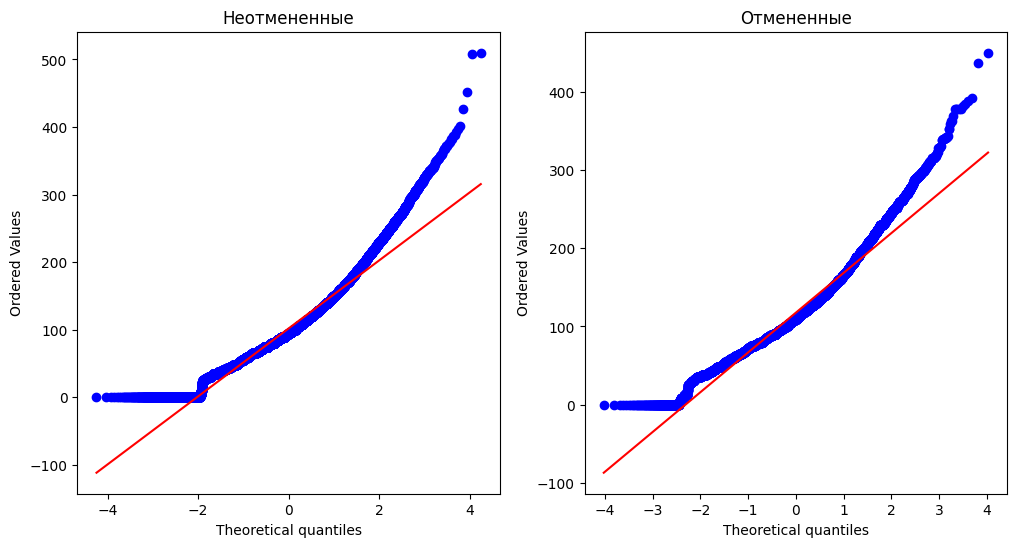

In [84]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
stats.probplot(adr_0, dist='norm', plot= plt) #из дз
plt.title('Неотмененные')

plt.subplot(1,2,2)
stats.probplot(adr_1, dist='norm', plot= plt)
plt.title('Отмененные')

plt.show()

По визуализациям видно, что наши данные сильно отличаются от линии, отсюда и окончательный вердикт, данные не подчиняются нормальному закону распределения. Далее, проверим гомогенность дисперсий, а именно похожи ли дисперсии групп, для этого воспользуемся стат тестом Левена

In [85]:
levene = stats.levene(adr_0, adr_1)
levene

LeveneResult(statistic=np.float64(8.087848008202318), pvalue=np.float64(0.004457341361838067))

Дисперсии не похожи, p_value меньше 0.05, поэтому диспресии статистически различаются. Теперь попробуем перейти к нашим основным гипотезам, группы не подчиняются нормальному закону распределения, дисперсии не равны, используем тет Мана Уитни

In [86]:
mann = stats.mannwhitneyu(adr_0, adr_1)
mann

MannwhitneyuResult(statistic=np.float64(616099276.0), pvalue=np.float64(0.0))

In [87]:
ttest = stats.ttest_ind(adr_0, adr_1)
ttest

TtestResult(statistic=np.float64(-40.02983227808719), pvalue=np.float64(0.0), df=np.float64(87162.0))

In [88]:
ttest = stats.ttest_ind(adr_0, adr_1, equal_var= False)
ttest

TtestResult(statistic=np.float64(-39.840828272754806), pvalue=np.float64(0.0), df=np.float64(42734.9276032877))

Все использованные статтесты показали крайне малые p_value, что говорит о том, что мы, во-первых, отвергаем нулевую гипотезу и принимаем альтернативную о том, что различия распределений adr в группах статистически значимые, а именно в группе с неотмененными бронированиями меньше, цена там меньше (узнали благодаря ттесту и welch тесту). 

Во-вторых, как описано раннее, также использовались ттест и welch тест. Согласно критериям использования ттеста, мы должны иметь нормальное распределение данных(чего нет), и гомогенность дисперсий(чего нет). Но если мы можем списать нормальность распределения на ЦПТ(помогает при больших выборках), гомогенность дисперсий отсутствует. Несмотря на это, мы решили ее использовать для сравнительного анализа, также использовали welch test, который помогает с проблемой отсутствия гомогенности дисперсий, тем самым мы можеем использовать помимо мана уитни еще и welch.

В итоге, в ходе проверки гипотез и сравнительного анализа(который также показал в какую сторону они не равны), все использованные критерии показали p_value < 0.05, что в свою очередь указывает на устойчивый вывод о том, что распределения не равны.

### Посмотрим теперь на признаки adr и customer_type, сформулируем и проверим гипотезы

Для начала посмотрим на визуализацию небольшую боксплотов по адр и типам клиентов

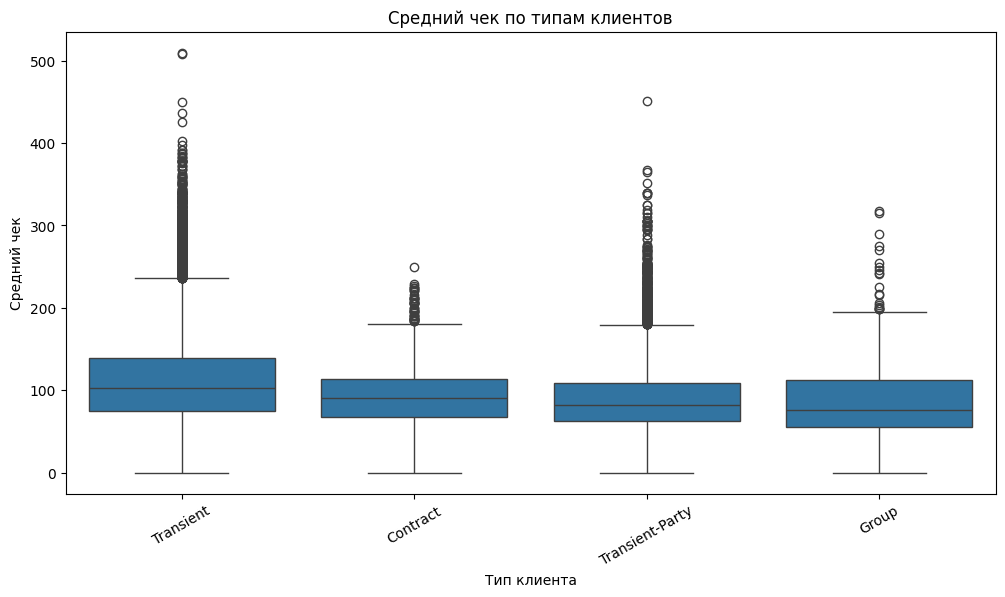

In [89]:
plt.figure(figsize=(12,6))
sns.boxplot(df, x='customer_type', y='adr')

plt.title('Средний чек по типам клиентов')
plt.xlabel('Тип клиента')
plt.ylabel('Средний чек')
plt.xticks(rotation=30)

plt.show()

По визуализации видны огромное количество выбросов (что нормально из-за adr), также распредление групп визуально отличается, у кого-то медаиана выше, у кого-то ниже. Помимо этого, распределение adr не подчиняется нормальному закону, как мы выяснили ранее в гипотезе о adr с таргетом.

Теперь подготовим группы, так как признак customer_type распределен на 4 группы, нужно также их сейчас поделить

In [90]:
transient = df[df['customer_type'] == 'Transient']['adr']
transient_party = df[df['customer_type'] == 'Transient-Party']['adr']
contract = df[df['customer_type'] == 'Contract']['adr']
group = df[df['customer_type'] == 'Group']['adr']

Группы поделили, все готово. Исходя из предыдущего маркдауна и независимых групп (customer_type это группирующий независимый признак с 4 "подгруппами", то есть больше двух) - делаем вывод, что можно использовать критерий краскела уоллиса

**Сформлируем гипотезы:**

H0: Распределение adr одинаково для всех типов клиентов

H1: Хотя бы у одного типа распределение adr отличается

In [91]:
kruskal = stats.kruskal(transient, transient_party, contract, group)
kruskal

KruskalResult(statistic=np.float64(2439.091866441936), pvalue=np.float64(0.0))

Мы получили крайне малое значение p-value, что значит что мы отвергаем нулевую гипотезу в сторону H1. Есть статистически значимое различие adr хотя бы в одной группе. Но этот стат тест говорит о том, что точно хотя бы одна и неизвестно какая группа отличается, теперь дополним это тем, какие именно группы отличаются. Посчитаем медианные и средние значения по группам

In [92]:
df.groupby('customer_type')['adr'].median().sort_values(ascending=False) #медианные 

customer_type
Transient          102.09
Contract            90.90
Transient-Party     81.43
Group               75.40
Name: adr, dtype: float64

In [93]:
df.groupby('customer_type')['adr'].mean().sort_values(ascending=False) #средние

customer_type
Transient          110.098350
Contract            92.780682
Transient-Party     87.840097
Group               86.154117
Name: adr, dtype: float64

По результатам замечаем, что наиболее высокий adr у типа transient (обычный клиент), тогда как у group наименьшее.

## Итог

В рамках всей работы анализа датасета, мы исследовали задачу выявления возможных факторов, которые влияют на отмену бронирования, что также влияет на выручку отеля. 

Изначально, провели предобработку, EDA, ознакомились с каждым признаком в отдельности, особое внимание уделяли важным признакам. Исходя из проделанной работы вытекли гипотезы, которые мы проверили и сделали выводы. 

Увидели, что City Hotel в целом хуже реализует бронирования, то есть между отелями есть разница, так что помимо общих рекомендаций важно разобраться какие факторы негативно влияют на работу этого отеля, и это не только про те, что были у нас в датасете.

Одна из гипотез была о том, что у отмененных бронирований средний чек выше, что подтвердила статистическая проверка. Отсюда делаем вывод, что более дорогие бронирования в основном дороже стоят, чем неотмененные, что в свою очередь несет для отеля финансовый убыток.

Также, мы проверили гипотезу о различиях среднего чека между типами клиентов. Статистический тест это подтвердил и далее мы добавили дополнительное уточнение о том, какие именно типы имеют бОльшие медианные и средние значения adr. Это дополняет гипотезу выше, то есть если средний чек связан с риском отмены, то понимание того, какие типы клиентов дают бОльшую выручку может помочь управлять ей и оценивать риски ее потери.

Также, помимо этого, мы дополнительно проверили несколько гипотез и сделали следующие выводы:
- разные типы гостей по-разному ведут себя в плане отмен их бронирований, то есть нужно также сегментировать людей и не применять ко всем один и тот же подход
- риск отмены отличается между различными каналами привлечения клиентов, из-за чего нужно менять подход в работе с разными каналами, в частности, это важно для работы с онлайн агенствами

**Общий вывод**
Риск отмены зависит не от одного фактора, а от комбинации цены, условий бронирования, типов клиента, канала продаж и др. По этим и другим причинам, отелю стоит использовать разные правила бронирования и подходы к работе с клиентами.